In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor']   = '#1a1a2e'
plt.rcParams['axes.edgecolor']   = '#444466'
plt.rcParams['axes.labelcolor']  = '#ccccee'
plt.rcParams['xtick.color']      = '#ccccee'
plt.rcParams['ytick.color']      = '#ccccee'
plt.rcParams['text.color']       = '#ccccee'
plt.rcParams['grid.color']       = '#2a2a4a'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5
PALETTE = ['#7b68ee', '#20b2aa', '#ff6b6b', '#ffd700', '#00ced1']

df = pd.read_csv('finanzas_cft_250.csv')
print(df.shape)
df.head(10)

(260, 6)


,ID_Transaccion,Fecha,Detalle,Monto_CLP,Sede,Estado
0,5000,2023-01-01,Beca Alimentación,1518165.0,Valdivia,Pagado
1,5001,2023-01-02,Mantención Sede,2250000.0,Panguipulli,Pendiente
2,5002,2023-01-03,Pago Arancel,142948.0,Valdivia,Pagado
3,5003,2023-01-04,Beca Alimentación,1642880.0,La Unión,Pagado
4,5004,2023-01-05,Beca Alimentación,417690.0,La Unión,Pendiente
5,5005,2023-01-06,Mantención Sede,514046.0,La Unión,Pendiente
6,5006,2024-03-15,Pago Arancel,36959.0,Valdivia,Pagado
7,5007,2023-01-08,Pago Arancel,1813792.0,La Unión,Pendiente
8,5008,2023-01-09,Beca Alimentación,1969109.0,La Unión,Pagado
9,5009,2023-01-10,Compra Insumos,1853756.0,Valdivia,Pagado


## 1. Auditoría inicial

In [2]:
print('=== dtypes ===')
print(df.dtypes)
print('\n=== nulos ===')
print(df.isnull().sum())
print('\n=== describe ===')
df.describe(include='all')

=== dtypes ===
ID_Transaccion      int64
Fecha              object
Detalle            object
Monto_CLP         float64
Sede               object
Estado             object
dtype: object

=== nulos ===
ID_Transaccion     0
Fecha              0
Detalle            0
Monto_CLP         15
Sede               0
Estado             0
dtype: int64

=== describe ===


,ID_Transaccion,Fecha,Detalle,Monto_CLP,Sede,Estado
count,260.000000,260,260,2.450000e+02,260,260
unique,NaN,237,4,NaN,4,2
top,NaN,2024-03-15,Mantención Sede,NaN,Valdivia,Pagado
freq,NaN,10,71,NaN,105,139
mean,5125.700000,NaN,NaN,1.183171e+06,NaN,NaN
std,71.957586,NaN,NaN,7.619726e+05,NaN,NaN
min,5000.000000,NaN,NaN,-5.000000e+04,NaN,NaN
25%,5064.750000,NaN,NaN,4.762430e+05,NaN,NaN
50%,5126.500000,NaN,NaN,1.134043e+06,NaN,NaN
75%,5188.250000,NaN,NaN,1.862191e+06,NaN,NaN


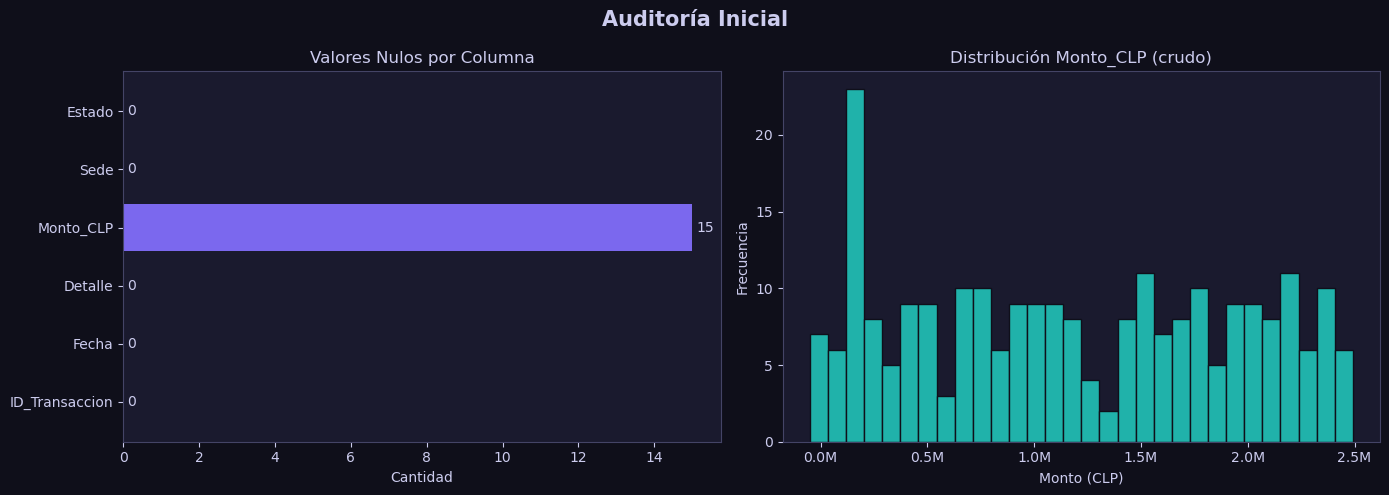

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Auditoría Inicial', fontsize=15, fontweight='bold', color='#ccccee')

nulos = df.isnull().sum()
axes[0].barh(nulos.index, nulos.values, color=PALETTE[0])
axes[0].set_title('Valores Nulos por Columna')
axes[0].set_xlabel('Cantidad')
for i, v in enumerate(nulos.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=10)

axes[1].hist(df['Monto_CLP'].dropna(), bins=30, color=PALETTE[1], edgecolor='#0f0f1a')
axes[1].set_title('Distribución Monto_CLP (crudo)')
axes[1].set_xlabel('Monto (CLP)')
axes[1].set_ylabel('Frecuencia')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

## 2. Pilar I — Completitud (valores nulos)

In [4]:
mediana_por_detalle = df.groupby('Detalle')['Monto_CLP'].median()
df['Monto_CLP'] = df.apply(
    lambda row: mediana_por_detalle[row['Detalle']]
    if pd.isnull(row['Monto_CLP']) else row['Monto_CLP'],
    axis=1
)
print('Nulos restantes en Monto_CLP:', df['Monto_CLP'].isnull().sum())

Nulos restantes en Monto_CLP: 0


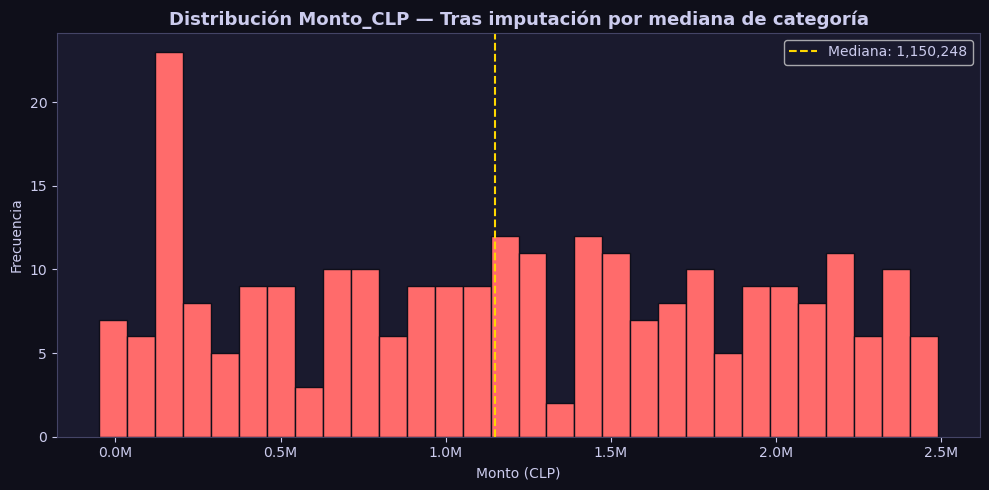

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Distribución Monto_CLP — Tras imputación por mediana de categoría', fontsize=13, fontweight='bold')
ax.hist(df['Monto_CLP'], bins=30, color=PALETTE[2], edgecolor='#0f0f1a')
ax.set_xlabel('Monto (CLP)')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.axvline(df['Monto_CLP'].median(), color=PALETTE[3], linestyle='--', label=f'Mediana: {df["Monto_CLP"].median():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Pilar II — Consistencia (normalización de categorías)

In [6]:
print('Valores únicos en Sede (antes):', df['Sede'].unique())

df['Sede'] = df['Sede'].replace({'VLDV': 'Valdivia'})
df['Sede'] = df['Sede'].str.strip().str.title()
df['Detalle'] = df['Detalle'].str.strip().str.title()
df['Estado'] = df['Estado'].str.strip().str.title()

print('Valores únicos en Sede (después):', df['Sede'].unique())

Valores únicos en Sede (antes): ['Valdivia' 'Panguipulli' 'La Unión' 'VLDV']
Valores únicos en Sede (después): ['Valdivia' 'Panguipulli' 'La Unión']


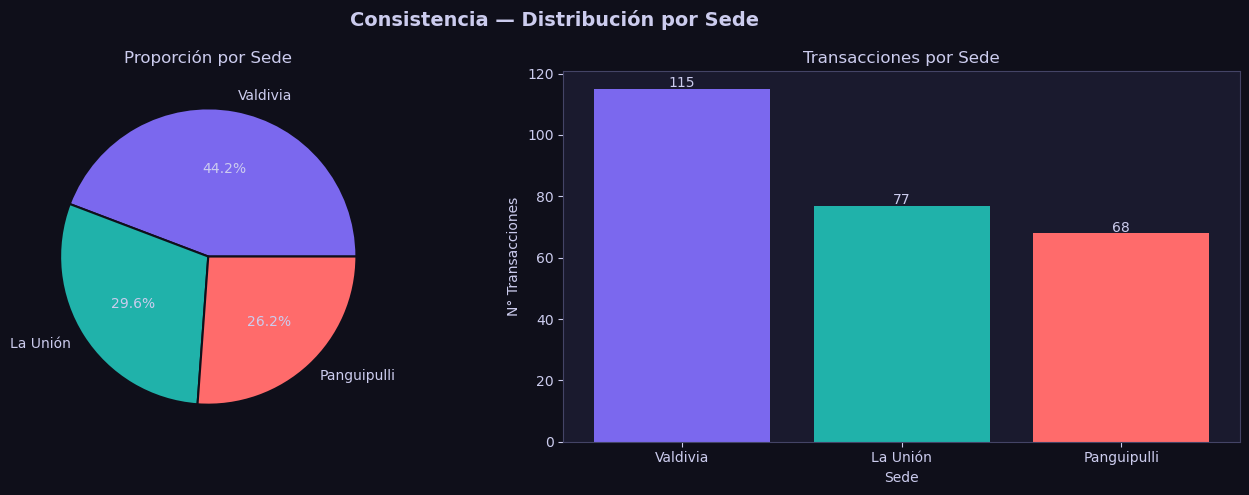

In [7]:
conteo_sede = df['Sede'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Consistencia — Distribución por Sede', fontsize=14, fontweight='bold', color='#ccccee')

axes[0].pie(
    conteo_sede.values, labels=conteo_sede.index,
    autopct='%1.1f%%', colors=PALETTE,
    textprops={'color': '#ccccee'},
    wedgeprops={'edgecolor': '#0f0f1a', 'linewidth': 1.5}
)
axes[0].set_title('Proporción por Sede')

axes[1].bar(conteo_sede.index, conteo_sede.values, color=PALETTE[:len(conteo_sede)])
axes[1].set_title('Transacciones por Sede')
axes[1].set_xlabel('Sede')
axes[1].set_ylabel('N° Transacciones')
for i, v in enumerate(conteo_sede.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Pilar III — Validez (valores negativos y fechas anómalas)

In [8]:
df['Fecha'] = pd.to_datetime(df['Fecha'])

fecha_min_valida = pd.Timestamp('2023-01-01')
fecha_max_valida = pd.Timestamp('2023-12-31')

mask_fecha_invalida = (df['Fecha'] < fecha_min_valida) | (df['Fecha'] > fecha_max_valida)
print('Registros con fecha fuera de rango 2023:', mask_fecha_invalida.sum())
print(df[mask_fecha_invalida][['ID_Transaccion', 'Fecha']].to_string())

df = df[~mask_fecha_invalida].copy()

mask_negativo = df['Monto_CLP'] < 0
print('\nRegistros con Monto_CLP negativo:', mask_negativo.sum())
df = df[~mask_negativo].copy()

print('\nShape tras limpieza de validez:', df.shape)

Registros con fecha fuera de rango 2023: 15
     ID_Transaccion      Fecha
6              5006 2024-03-15
16             5016 2024-03-15
23             5023 2024-03-15
28             5028 2014-05-20
31             5031 2024-03-15
89             5089 2014-05-20
93             5093 2014-05-20
131            5131 2024-03-15
154            5154 2024-03-15
179            5179 2024-03-15
191            5191 2024-03-15
202            5202 2014-05-20
214            5214 2024-03-15
240            5240 2014-05-20
244            5244 2024-03-15

Registros con Monto_CLP negativo: 5

Shape tras limpieza de validez: (240, 6)


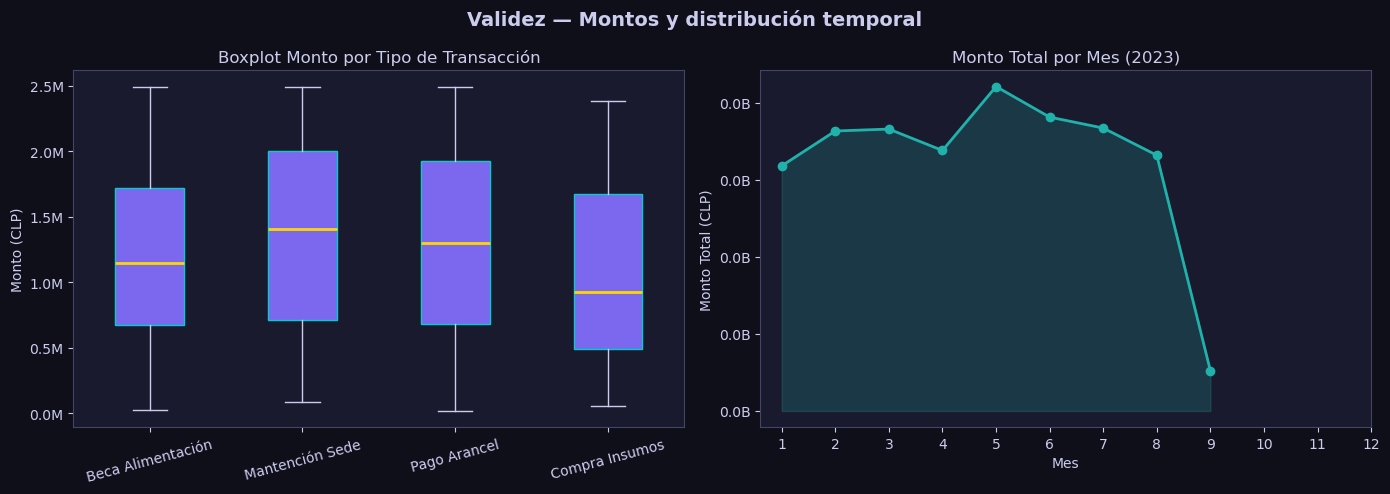

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Validez — Montos y distribución temporal', fontsize=14, fontweight='bold', color='#ccccee')

axes[0].boxplot(
    [df[df['Detalle'] == d]['Monto_CLP'].values for d in df['Detalle'].unique()],
    labels=df['Detalle'].unique(),
    patch_artist=True,
    boxprops=dict(facecolor=PALETTE[0], color=PALETTE[4]),
    medianprops=dict(color=PALETTE[3], linewidth=2),
    whiskerprops=dict(color='#ccccee'),
    capprops=dict(color='#ccccee'),
    flierprops=dict(marker='o', markerfacecolor=PALETTE[2], markersize=4)
)
axes[0].set_title('Boxplot Monto por Tipo de Transacción')
axes[0].set_ylabel('Monto (CLP)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=15)

df['Mes'] = df['Fecha'].dt.month
monto_mes = df.groupby('Mes')['Monto_CLP'].sum()
axes[1].plot(monto_mes.index, monto_mes.values, marker='o', color=PALETTE[1], linewidth=2, markersize=6)
axes[1].fill_between(monto_mes.index, monto_mes.values, alpha=0.2, color=PALETTE[1])
axes[1].set_title('Monto Total por Mes (2023)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Monto Total (CLP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## 5. Pilar IV — Unicidad (duplicados)

In [10]:
print('Duplicados por ID_Transaccion:', df.duplicated(subset='ID_Transaccion').sum())
print('Filas duplicadas completas:', df.duplicated().sum())

df = df.drop_duplicates(subset='ID_Transaccion', keep='first').reset_index(drop=True)

print('Shape final sin duplicados:', df.shape)

Duplicados por ID_Transaccion: 10
Filas duplicadas completas: 9
Shape final sin duplicados: (230, 7)


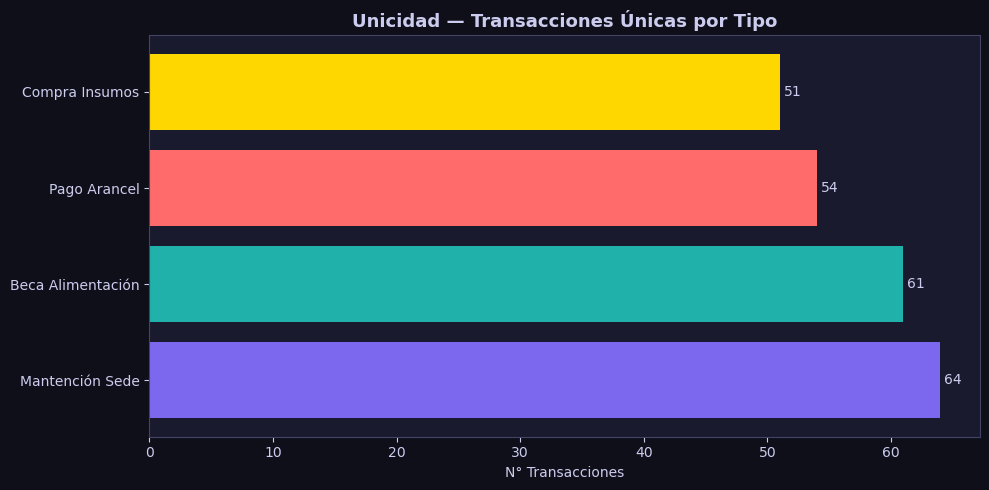

In [11]:
conteo_detalle = df['Detalle'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(conteo_detalle.index, conteo_detalle.values, color=PALETTE[:len(conteo_detalle)])
ax.set_title('Unicidad — Transacciones Únicas por Tipo', fontsize=13, fontweight='bold')
ax.set_xlabel('N° Transacciones')
for bar, v in zip(bars, conteo_detalle.values):
    ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2, str(v), va='center')
plt.tight_layout()
plt.show()

## 6. Pilar V — Exactitud (tipos de datos y conversión final)

In [12]:
df['ID_Transaccion'] = df['ID_Transaccion'].astype(int)
df['Monto_CLP'] = df['Monto_CLP'].astype(float)
df['Sede'] = df['Sede'].astype('category')
df['Detalle'] = df['Detalle'].astype('category')
df['Estado'] = df['Estado'].astype('category')

print(df.dtypes)
df.describe(include='all')

ID_Transaccion             int32
Fecha             datetime64[ns]
Detalle                 category
Monto_CLP                float64
Sede                    category
Estado                  category
Mes                        int32
dtype: object


,ID_Transaccion,Fecha,Detalle,Monto_CLP,Sede,Estado,Mes
count,230.000000,230,230,2.300000e+02,230,230,230.000000
unique,NaN,NaN,4,NaN,3,2,NaN
top,NaN,NaN,Mantención Sede,NaN,Valdivia,Pagado,NaN
freq,NaN,NaN,64,NaN,99,122,NaN
mean,5124.508696,2023-05-05 12:12:31.304347904,NaN,1.239809e+06,NaN,NaN,4.652174
min,5000.000000,2023-01-01 00:00:00,NaN,1.805100e+04,NaN,NaN,1.000000
25%,5064.250000,2023-03-06 06:00:00,NaN,6.610240e+05,NaN,NaN,3.000000
50%,5123.500000,2023-05-04 12:00:00,NaN,1.287064e+06,NaN,NaN,5.000000
75%,5185.750000,2023-07-05 18:00:00,NaN,1.869492e+06,NaN,NaN,7.000000
max,5249.000000,2023-09-07 00:00:00,NaN,2.492154e+06,NaN,NaN,9.000000


## 7. Análisis exploratorio final

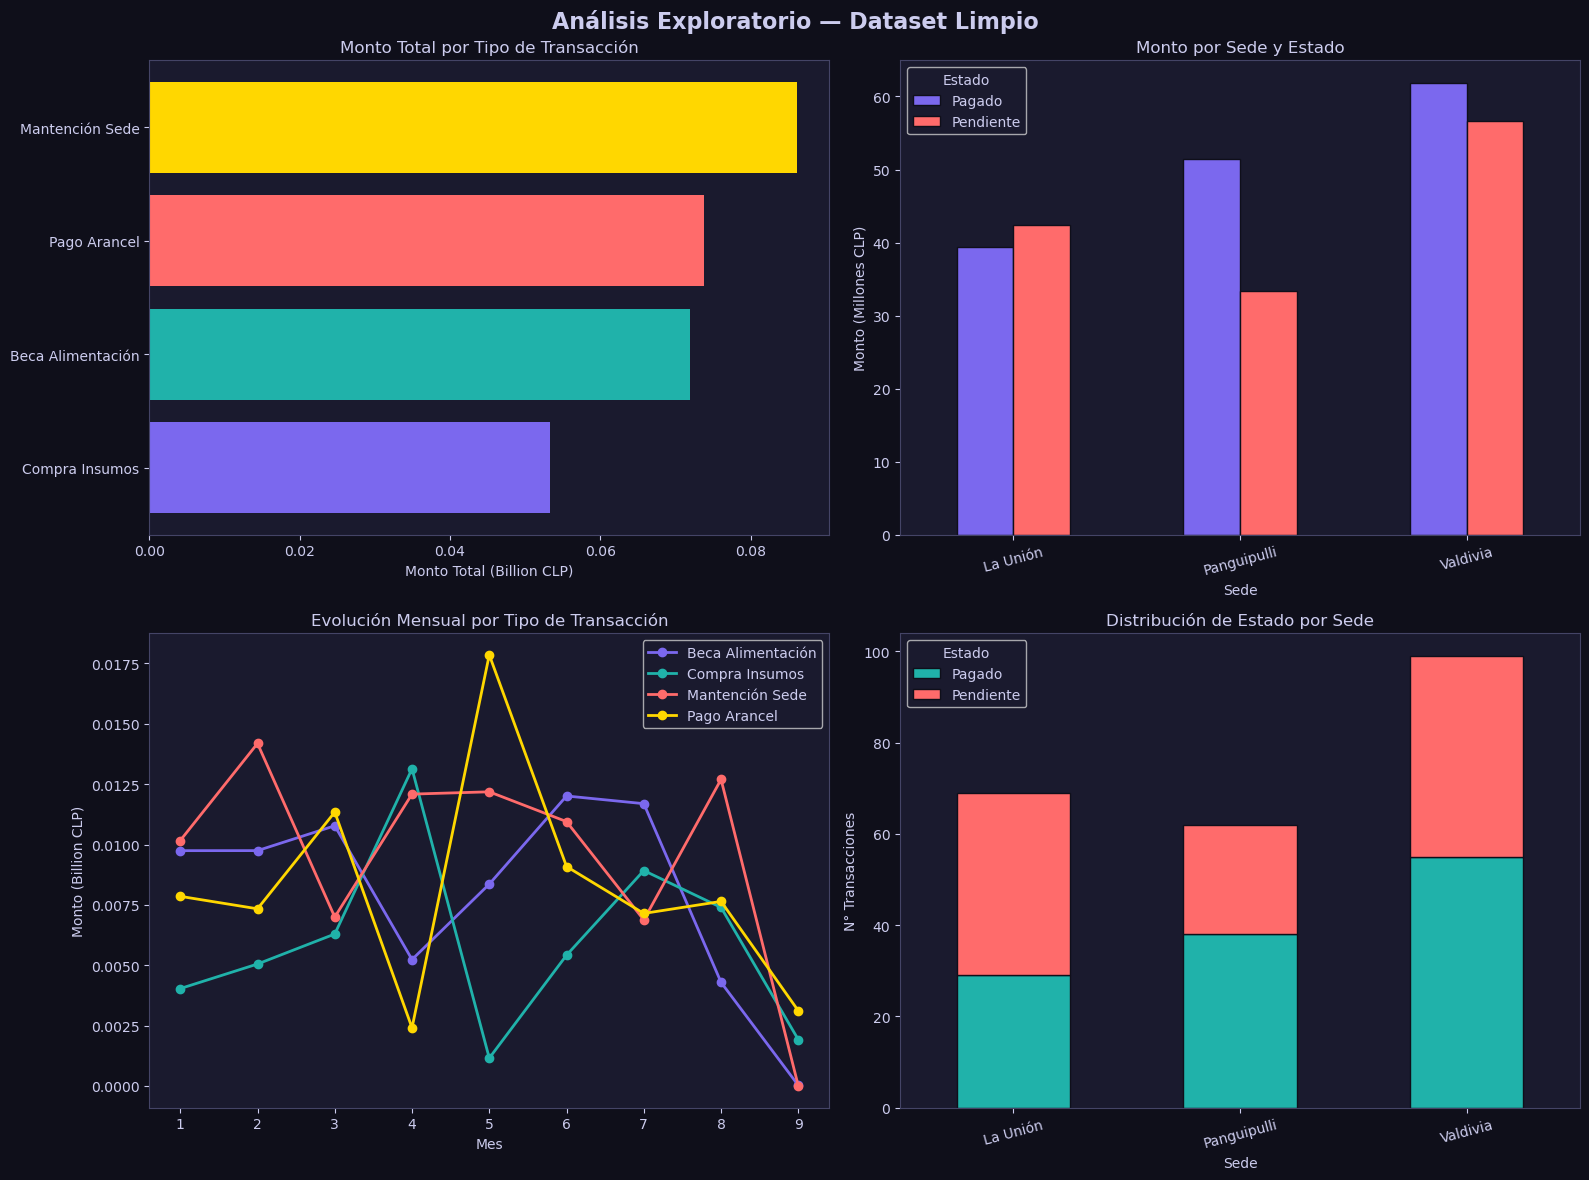

Dataset limpio: (230, 7)


,ID_Transaccion,Fecha,Detalle,Monto_CLP,Sede,Estado,Mes
0,5000,2023-01-01,Beca Alimentación,1518165.0,Valdivia,Pagado,1
1,5001,2023-01-02,Mantención Sede,2250000.0,Panguipulli,Pendiente,1
2,5002,2023-01-03,Pago Arancel,142948.0,Valdivia,Pagado,1
3,5003,2023-01-04,Beca Alimentación,1642880.0,La Unión,Pagado,1
4,5004,2023-01-05,Beca Alimentación,417690.0,La Unión,Pendiente,1


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Exploratorio — Dataset Limpio', fontsize=16, fontweight='bold', color='#ccccee')

monto_detalle = df.groupby('Detalle')['Monto_CLP'].sum().sort_values(ascending=True)
axes[0, 0].barh(monto_detalle.index, monto_detalle.values / 1e9, color=PALETTE[:len(monto_detalle)])
axes[0, 0].set_title('Monto Total por Tipo de Transacción')
axes[0, 0].set_xlabel('Monto Total (Billion CLP)')

pivot = df.pivot_table(values='Monto_CLP', index='Sede', columns='Estado', aggfunc='sum') / 1e6
pivot.plot(kind='bar', ax=axes[0, 1], color=[PALETTE[0], PALETTE[2]], edgecolor='#0f0f1a')
axes[0, 1].set_title('Monto por Sede y Estado')
axes[0, 1].set_ylabel('Monto (Millones CLP)')
axes[0, 1].set_xlabel('Sede')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend(title='Estado', facecolor='#1a1a2e')

monto_mes_detalle = df.groupby(['Mes', 'Detalle'])['Monto_CLP'].sum().unstack()
for i, col in enumerate(monto_mes_detalle.columns):
    axes[1, 0].plot(monto_mes_detalle.index, monto_mes_detalle[col] / 1e9,
                    marker='o', color=PALETTE[i % len(PALETTE)], label=col, linewidth=2)
axes[1, 0].set_title('Evolución Mensual por Tipo de Transacción')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Monto (Billion CLP)')
axes[1, 0].set_xticks(range(1, 10))
axes[1, 0].legend(facecolor='#1a1a2e')

estado_counts = df.groupby(['Sede', 'Estado']).size().unstack(fill_value=0)
estado_counts.plot(kind='bar', stacked=True, ax=axes[1, 1],
                   color=[PALETTE[1], PALETTE[2]], edgecolor='#0f0f1a')
axes[1, 1].set_title('Distribución de Estado por Sede')
axes[1, 1].set_xlabel('Sede')
axes[1, 1].set_ylabel('N° Transacciones')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(title='Estado', facecolor='#1a1a2e')

plt.tight_layout()
plt.savefig('finanzas_eda_final.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Dataset limpio:', df.shape)
df.head()

In [14]:
df.to_csv('finanzas_cft_250_LIMPIO.csv', index=False)
print('Archivo exportado: finanzas_cft_250_LIMPIO.csv')

Archivo exportado: finanzas_cft_250_LIMPIO.csv
